In [12]:
from langchain_openai import ChatOpenAI
from langchain.messages import HumanMessage,SystemMessage
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_community.document_loaders import DirectoryLoader,PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import Chroma, FAISS
from langchain_openai import ChatOpenAI,OpenAIEmbeddings
from langgraph.graph import StateGraph,START, END,MessagesState
from typing import TypedDict,Annotated,Literal
import os 
import sys
sys.path.insert(1, r'C:\Users\Dharmendra Vartika\LLM\env')
sys.path.insert(2, r'C:\Users\Dharmendra Vartika\LLM\langchain_document_loader')
from enviorment import load_env
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_core.tools import tool
#from pydirectoryloader import rag_function
import os 
load_env()
from langchain_community.tools.tavily_search import TavilySearchResults




In [24]:
@tool
def rag_function(question:str):
    """function to get Dharmendra data from the resume"""
#loader=PyPDFLoader('dl-curriculum.pdf')
    #print ('inside  rag_function question')
    loader=DirectoryLoader(path=r'C:\Users\Dharmendra Vartika\LLM\langchain_document_loader\Books',
                       glob='*Dharmendra_Data_Manager.pdf',
                       loader_cls=PyPDFLoader)
#l=loader.load()
    l=loader.lazy_load()
    text_splitter=RecursiveCharacterTextSplitter(chunk_size=1000,chunk_overlap=200)
    documents=text_splitter.split_documents(l)
    db=FAISS.from_documents(documents, OpenAIEmbeddings())
    retriever=db.as_retriever(search_type='similarity',search_kwargs={"k":2})
    results = retriever.invoke(question)
    return "\n".join([doc.page_content for doc in results])
search_Tavily = TavilySearchResults(max_results=2)
from langchain_community.tools import DuckDuckGoSearchRun
search_tool = DuckDuckGoSearchRun(region="us-en")
tools = [rag_function,search_Tavily,search_tool]
#tool_node = ToolNode(tools)
#model_llm=ChatOpenAI(model="gpt-3.5-turbo", temperature=0).bind_tools(tools).bind_tools(tools)
model=ChatOpenAI()

In [45]:
query='I wanted to know what is the impression of Prime mininster Modi in the current tenure'
search_Tavily1 = TavilySearchResults(max_results=1)
raw=search_Tavily1.invoke({"query": query})

In [48]:
raw[0]['content']

'EPA Senior Congress leader Rahul Gandhi (L) and Samajwadi Party president Akhilesh Yadav (R) from Indian National Developmental Inclusive Alliance (I.N.D.I.A), a multi-party political alliance against ruling and Narendra Modi led Bhartiya Janta party, hold a joint press conference in Ghaziabad, Uttar Pradesh, India, 17 April 2024.\n\nSupporters praise the PM for "never taking a break". His relentless programmes and constant media coverage consolidate the impression that he is always working. [...] Supporters claim he is a strong, efficient leader who has delivered on promises. Critics allege his government has weakened federal institutions; cracked down on dissent and press freedom; and that India\'s Muslim minority feels threatened under his rule.\n\n"Mr Modi has very staunch admirers and very strong critics. Either you like him or you dislike him," says political analyst Ravindra Reshme. [...] Back in Varanasi, not everyone is so impressed. Little has changed in Lohta, a Muslim-domi

In [31]:
from langgraph_supervisor import create_supervisor

In [ ]:
assistant_system_message = SystemMessage(content=("""
You are a friendly, conversational financial assistant."""))
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(
    model=model,
    tools=tools,
    prompt=assistant_system_message ## optional 
)

C:\Users\Dharmendra Vartika\AppData\Local\Temp\ipykernel_25872\1769913478.py:5: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


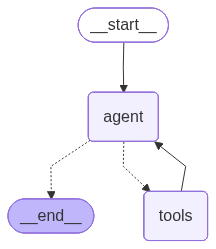

In [30]:
agent

In [37]:
ques="I wanted to know what is the impression of Prime mininster Modi in the current tenure "
messages = agent.invoke({"messages": [HumanMessage(content=ques)]})
for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

I wanted to know what is the impression of Prime mininster Modi in the current tenure 
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_T866yl33dsx0A9Z1Hf2VDiO5)
 Call ID: call_T866yl33dsx0A9Z1Hf2VDiO5
  Args:
    query: impression of Prime Minister Modi in the current tenure
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Narendra Modi's India: A decade of popularity and polarisation - BBC", "url": "https://www.bbc.com/news/world-asia-india-69010109", "content": "EPA Senior Congress leader Rahul Gandhi (L) and Samajwadi Party president Akhilesh Yadav (R) from Indian National Developmental Inclusive Alliance (I.N.D.I.A), a multi-party political alliance against ruling and Narendra Modi led Bhartiya Janta party, hold a joint press conference in Ghazia

In [57]:
import json
json.loads(data.decode("utf-8"))

{'status': True,
 'message': 'Success',
 'timestamp': 1761744124212,
 'data': {'totalRecords': 9213,
  'totalPages': 307,
  'data': [{'restaurantsId': 'Restaurant_Review-g304554-d27145029-Reviews-Avartana_ITC_Maratha-Mumbai_Maharashtra',
    'locationId': 27145029,
    'name': 'Avartana - ITC Maratha',
    'averageRating': 5,
    'userReviewCount': 223,
    'currentOpenStatusCategory': 'OPENING',
    'currentOpenStatusText': 'Opens in 7 min',
    'priceTag': '$$$$',
    'hasMenu': False,
    'menuUrl': None,
    'isDifferentGeo': False,
    'parentGeoName': 'Mumbai',
    'distanceTo': None,
    'awardInfo': {'year': 2025, 'awardType': 'BOTB'},
    'isLocalChefItem': False,
    'isPremium': False,
    'isStoryboardPublished': False,
    'establishmentTypeAndCuisineTags': ['Indian'],
    'offers': {'hasDelivery': None,
     'hasReservation': None,
     'slot1Offer': None,
     'slot2Offer': None,
     'restaurantSpecialOffer': None},
    'heroImgUrl': 'https://dynamic-media-cdn.tripadvis

In [73]:
import http.client

conn = http.client.HTTPSConnection("real-time-news-data.p.rapidapi.com")

headers = {
    'x-rapidapi-key': "64bf35c7b0mshdffa12c25d62d35p1927fejsn6b5b49ce1713",
    'x-rapidapi-host': "real-time-news-data.p.rapidapi.com"
}

conn.request("GET", "/search?query=lucknow&limit=10&time_published=anytime&country=IN&lang=en", headers=headers)

res = conn.getresponse()
data = res.read()

print(data.decode("utf-8"))

{"status":"OK","request_id":"e69b4dfa-6743-44c8-b6d5-85b6d1d0c6c8","data":[{"article_id":"CBMi5AFBVV95cUxOTktFNkVvMVFWV2hsbHFIRkpkcDlKdTZGSVg5am1xbTdfNmxFT3lVMHpibnhVZUVpbnV2YlE2aXFmeWNVeFhfVWxiRzN3eGVhVGVlLVNhRVJuRkhSMDR0cm9Xb2w1OW11eFZSTThiZ0FkQ0ZlLTMtVUNwZElRdEQ2Mks1ZUkwYWx2cHJTLWNjVURGMTkwT2dZeUhfemdvRUkxSDVjRTd2WUNyQ0h5RW42WkZPWW1PY2Z5aDBmM2k5Y0NJYWJJa3V0U1Fueld6cWZlbEcwY3N4cERQanl1YUFPT0gzRTPSAeoBQVVfeXFMTXptZU1odmR0bXZKd3NYZDVMdzZiOXEtV29OT1JvWEk3MEdBc0FKQTlGcDlHS09CZXVzdVFrR29WRXhMWlQ4ekxNdzhwNDEtSmpiQ0paWEV1VVRUVVNpWWo1QnM5bmFUNjBzeXdxbmJ2dlN1cm45d2pOeGQxbV9NSjBnb1RHUTMwanAtOFZFaVIyOWpCbDRmNjlwREY4Wmp5WkNnOXNuQlk2cXhPaklHZEhRcTVPUjFvNmpBY25kb1M5Z19PdnNiMHlfN3EtaTJYMWtqcjlZSXdwZEFWR0x6TE8xaW5CNVdEM0x3","title":"Lucknow shocker: Woman, brother seek justice after assault by society members","link":"https://timesofindia.indiatimes.com/city/lucknow/lucknow-shocker-woman-brother-seek-justice-after-assault-by-society-members/articleshow/124868861.cms","snippet":"A viral video shows a

In [79]:
import json
s=[]
for i in json.loads(data.decode("utf-8"))['data']:
    s.append(i['snippet'])
news='/n '.join (s)

In [83]:
if json.loads(data.decode("utf-8"))['status']=='OK':
    print ('news there')
else:
    print('news not found')

news there
